In [ ]:
import sys
import muon as mu 
import numpy as np
import pandas as pd


# Change path to wherever you have repo locally
sys.path.append('/oak/stanford/groups/engreitz/Users/ymo/Tools/PerturbNMF/src')



from Interpretation.Plotting.src import plot_umap_per_gene, plot_top_program_per_gene, perturbed_gene_dotplot,\
                         plot_log2FC, plot_volcano, programs_dotplot, analyze_correlations, \
                         create_gene_correlation_waterfall, \
                         convert_with_mygene, convert_adata_with_mygene, read_npz, \
                         merge_pdfs_in_folder, merge_svgs_to_pdf, create_comprehensive_plot, rename_adata_gene_dictionary, \
                         rename_list_gene_dictionary, plot_umap_per_gene_guide, process_single_gene, parallel_gene_processing,\
                         compute_gene_correlation_matrix, compute_gene_waterfall_cor, \
                         plot_perturbation_vs_control

# Find perturbed gene & formatting check

In [ ]:
#IO path
save_path = "/oak/stanford/groups/engreitz/Users/ymo/Tools/cNMF_benchmarking"

# data path 
mdata_path = "/oak/stanford/groups/engreitz/Users/ymo/IGVF_ccperturbseq/Result/030526_100k_cells_100iter_allHVG_torch_halsvar_batch_e7_50/adata/cNMF_50_0_2.h5mu"
mdata_guide_path = "/oak/stanford/groups/engreitz/Users/ymo/IGVF_ccperturbseq/Result/030526_100k_cells_100iter_allHVG_torch_halsvar_batch_e7_50/adata/cNMF_50_0_2.h5mu"

# resourse path
perturb_path = "/oak/stanford/groups/engreitz/Users/ymo/IGVF_ccperturbseq/Result/030526_100k_cells_100iter_allHVG_torch_halsvar_batch_e7_50/Evaluation/50_0_2/50_CRT_D0.txt"
perturb_path_base = "/oak/stanford/groups/engreitz/Users/ymo/IGVF_ccperturbseq/Result/030526_100k_cells_100iter_allHVG_torch_halsvar_batch_e7_50/Evaluation/50_0_2/50_CRT"
file_to_dictionary = None
reference_gtf_path=None

# keys 
top_program = 10
prog_key = 'cNMF'
data_key = 'rna'
categorical_key = 'batch'
sample = ['D0', 'D1', 'D2', 'D3']
log2fc_col = 'approx_log2FC'
gene_name_key= 'symbol'
control_target_name = 'non-targeting'  # name of non-targeting control in guide_targets (e.g. 'non-targeting', 'CTRL')

# UMAP subsampling (set to None to plot all cells, or e.g. 0.1 for 10%)
umap_subsample_frac = 0.1

In [3]:
# read data
mdata = mu.read_h5mu(mdata_path)

In [ ]:
mdata_guide = mu.read(mdata_guide_path)

In [ ]:
# reformate if needed 
def _assign_guide(mdata, mdata_guide):

        mdata['rna'].obsm['X_pca'] =  mdata['cNMF'].obsm['X_pca'] 
        mdata['rna'].obsm['X_umap'] =  mdata['cNMF'].obsm['X_pca'] 

_assign_guide(mdata,mdata)  

In [ ]:
# check umap exist 
if 'X_umap' not in mdata['cNMF'].obsm:
    
    import scanpy as sc
    sc.pp.highly_variable_genes(mdata['rna'], n_top_genes=2000, subset=True)
    sc.tl.pca(mdata['rna'], n_comps=50)
    sc.pp.neighbors(mdata['rna'])
    sc.tl.umap(mdata['rna'])
    mdata['cNMF'].obsm['X_pca'] = mdata['rna'].obsm['X_pca'] 
    mdata['cNMF'].obsm['X_umap'] = mdata['rna'].obsm['X_umap']

In [4]:
# found detected perturbed gene
perturbed_gene = np.unique(mdata['cNMF'].uns["guide_targets"])
gene_list = mdata['rna'].var_names.tolist()
perturbed_gene_found = list(set(gene_list) & set(perturbed_gene.tolist()))

# sort list by alphabetical order 
perturbed_gene_found = sorted(perturbed_gene_found)
len(perturbed_gene_found) 

290

In [5]:
# select gene of interest
Target_Gene = perturbed_gene_found[2]
Target_Gene

'ACVR2A'

# UMAP

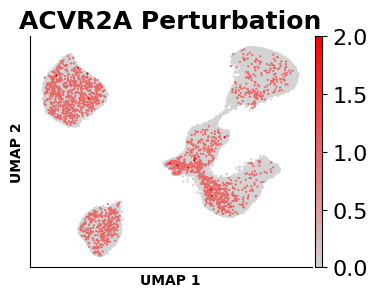

In [8]:
fg = plot_umap_per_gene_guide(mdata, Target_Gene, figsize = (4,3), show = True, size = 10, umap_subsample_frac=umap_subsample_frac)

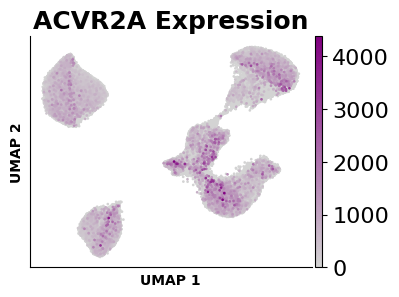

In [9]:
fg = plot_umap_per_gene(mdata, Target_Gene, ensembl_to_symbol_file=file_to_dictionary, figsize = (4,3), show = True, size = 15, umap_subsample_frac=umap_subsample_frac)

# Top x assigned programs

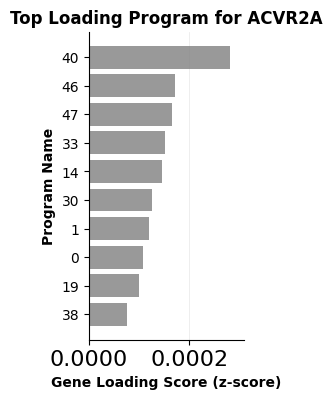

In [10]:
fg = plot_top_program_per_gene(mdata, Target_Gene=Target_Gene,  ensembl_to_symbol_file = None, top_n_programs =top_program, figsize = (2,4), show = True)

# Target KD

In [ ]:
fg = plot_perturbation_vs_control(mdata, Target_Gene, gene_name_key='symbol', ax=None, figsize=(3.2, 5.0), control_target_name=control_target_name)

# Dot plots

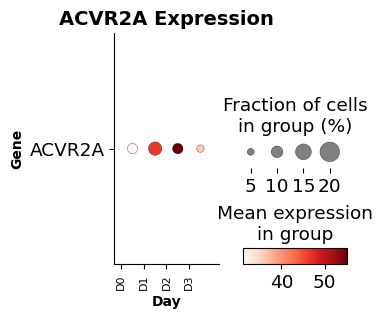

In [11]:
fg = perturbed_gene_dotplot(mdata, Target_Gene, dotplot_groupby = "batch", figsize = (3,3), show = True)

# Perturbation gene - Log2FC

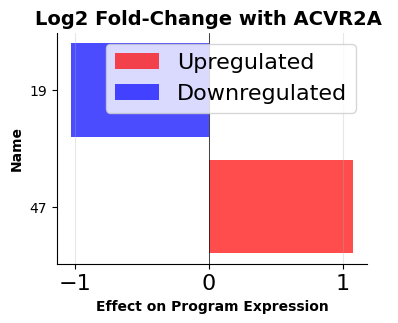

In [12]:

_,df = plot_log2FC(perturb_path, Target = Target_Gene, perturb_target_col = "target_name", perturb_program_col = "program_name", perturb_log2fc_col=log2fc_col, significance_threshold = 0.05, figsize = (4,3), show = True)

# Perturbation gene - volcano

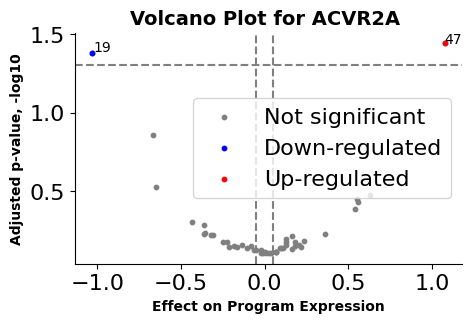

In [13]:

fg = plot_volcano(perturb_path, Target = Target_Gene, perturb_log2fc_col=log2fc_col, volcano_log2fc_min = -0.05, volcano_log2fc_max = 0.05, significance_threshold = 0.05, figsize = (5,3),show = True)

# Perturbation gene - dotplot

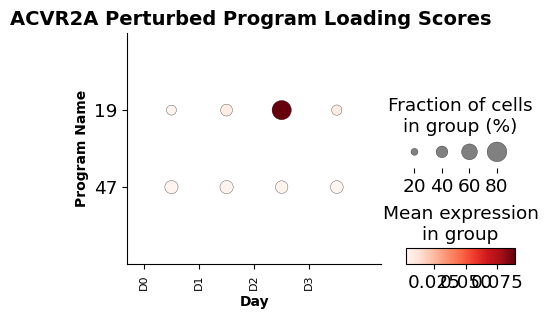

In [14]:

fg = programs_dotplot(mdata, program_list = df["program_name"].tolist(), dotplot_groupby =categorical_key, Target = Target_Gene, save_path = None, save_name = None, figsize = (5,3),show = True)

# Correlation of program

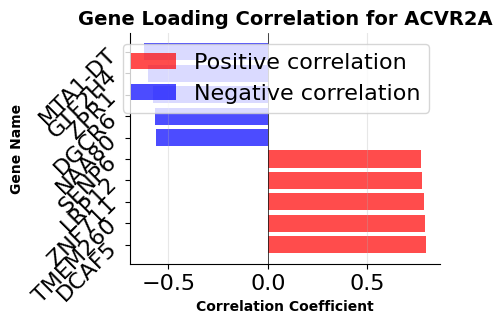

In [15]:
gene_correlation = compute_gene_correlation_matrix(mdata, ensembl_to_symbol_file = file_to_dictionary)

fg = analyze_correlations(gene_correlation, Target_Gene, top_corr_genes=5, save_path=None, 
 save_name=None, figsize = (4,3), show = True, ax=None)

# Waterfall plot

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


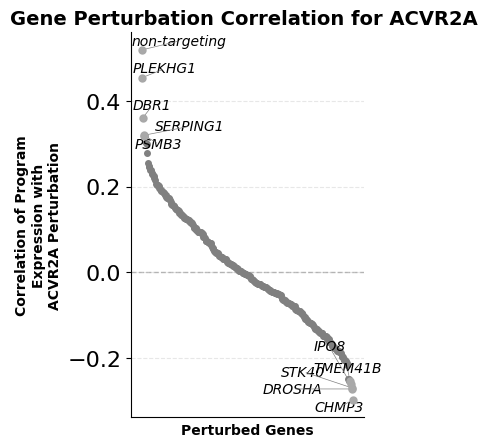

In [16]:

waterfall_correlation = compute_gene_waterfall_cor(perturb_path, perturb_log2fc_col=log2fc_col)
fg = create_gene_correlation_waterfall(waterfall_correlation, Target_Gene, top_corr_genes=5, save_path=None, 
                         save_name=None, figsize=(3, 5), show=True, ax=None, Day ="")


# Make PDF for gene

In [ ]:
waterfall_correlation = {}

for samp in sample:
    df = compute_gene_waterfall_cor(f"{perturb_path_base}_{samp}.txt", perturb_log2fc_col=log2fc_col)
    waterfall_correlation[samp] = (df)


gene_correlation = compute_gene_correlation_matrix(mdata)

In [ ]:
create_comprehensive_plot(
    mdata = mdata,
    gene_loading_corr_matrix = gene_correlation,
    perturb_corr_by_sample  = waterfall_correlation,
    perturb_path_base = perturb_path_base,
    Target_Gene = Target_Gene,
    ensembl_to_symbol_file =None,
    save_path="/oak/stanford/groups/engreitz/Users/ymo/Tools/PerturbNMF/src/Interpretation/JupterNote_Version",
    save_name="perturbed_gene_analysis_example",
    dotplot_groupby = categorical_key,
    perturb_log2fc_col=log2fc_col,
    sample = sample,
    figsize=(35, 40),
    show=True,
    PDF = True,
    umap_dot_size = 10,
    umap_subsample_frac=umap_subsample_frac,
    gene_name_key=gene_name_key,
    control_target_name=control_target_name
)

# Make PDFs for all genes

In [ ]:
# Graph all pdf 

os.makedirs(save_path, exist_ok=True)                                                                                                           

for gene in perturbed_gene_found:

    create_comprehensive_plot(
        mdata = mdata,
        perturb_path_base = perturb_path_base,
        Target_Gene = gene,
        gene_loading_corr_matrix = gene_correlation,
        perturb_corr_by_sample  = waterfall_correlation,
        ensembl_to_symbol_file = file_to_dictionary,
        save_path = save_path,
        save_name = gene,
        perturb_log2fc_col=log2fc_col,
        figsize=(30, 30),
        show=False,
        PDF = True,
        sample= sample,
        square_plots=True,
        umap_subsample_frac=umap_subsample_frac,
        control_target_name=control_target_name
    )

In [ ]:

merge_pdfs_in_folder(save_path, 'Gene.pdf')
#merge_svgs_to_pdf(save_path)

Found 100 PDF files
